# Avance 3. Baseline


El propósito de este notebook es establecer un modelo de referencia (baseline) para el pronóstico de la serie temporal de casos de depresión. Un modelo de referencia es fundamental en cualquier proyecto de machine learning porque:

1. Establece un punto de comparación: Sirve como una medida de rendimiento mínima que cualquier modelo más complejo (como SARIMA o modelos de machine learning) debe superar para justificar su complejidad.

2. Valida el entendimiento de los datos: Un buen modelo base demuestra que se han comprendido las características principales de la serie, como la tendencia y la estacionalidad.

## Librerías y Carga de Datos

* Se define si se utilizará Plotly para las gráficas y se importan las librerías necesarias para análisis de datos, visualización y modelado de series temporales.

Recomendaciones:  Para un mejor entendimiento de las gráficas o su uso local cambiar el valor de `USE_PLOTRLY` a `True`

In [1]:
USE_PLOTLY = True

### Librerías

In [2]:
import sys
sys.path.append('../../')

In [4]:
import pandas as pd
import numpy as np
from tabulate import tabulate
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2, f_classif
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
#!pip install holidays
from src.utils import helpers as func
from src.utils.ts_diagnostics import StationarityAnalyzer, analyze_decomposition

#!pip install prince
import prince as pr
import plotly.express as px

   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 1.3/1.3 MB 9.4 MB/s  0:00:00
   ---------------------------------------- 0.0/731.2 kB ? eta -:--:--
   ---------------------------------------- 731.2/731.2 kB 6.0 MB/s  0:00:00

   ---------------------------------------- 0/2 [altair]
   ---------------------------------------- 0/2 [altair]
   ---------------------------------------- 2/2 [prince]



### Carga de Datos

* Se carga el conjunto de datos procesado utilizando una función personalizada, preparando el DataFrame para el análisis.

In [6]:
# path = '../../data/processed/df_entidades_acum.parquet'
path = '../../data/processed/df_acumulado.parquet'
df = func.load_data(path,show_info=False)

Cargando datos desde: ../../data/processed/df_acumulado.parquet
Datos cargados exitosamente.


## Análisis de la Serie Temporal

### Serie Original por Casos Semanales Acumulados

* Se seleccionan las columnas relevantes y se grafica la serie temporal acumulada para observar su comportamiento general.

In [7]:
# Dataframe con las columnas necesarias para el análisis de series temporales
df_filtrado = df[['fecha', 'valor_acumulado_corregido']].copy()
df_filtrado.rename(columns={'valor_acumulado_corregido': 'valor'}, inplace=True)
x= 'fecha'
y= 'valor'
title = 'Serie de tiempo General acumulada (df_final)'
# Gráfica de línea con plotly / seaborn según selección del usuario
func.plot_timeseries(df_filtrado, x=x, y=y, title=title, plotly_engine=USE_PLOTLY)

#### Descripción de gráfico
Se realizaron las correcciones pertinentes al dataset para considerar los valores acumulados de todos los años pasados y se corrigieron los valores atípicos con interpolación. con ellos, se obtiene el gráfico mostrado arriba, en el cual, se puede confirmar que la serie temporal de casos de depresión exhibe una **fuerte y consistente tendencia de crecimiento** desde 2014. Esto valida que el ritmo constante de acumulación de casos a lo largo del tiempo es el patrón "normal". La serie es altamente predecible en su tendencia.

#### Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido

* Se descompone la serie en sus componentes de tendencia, estacionalidad y ruido para identificar patrones subyacentes.

In [8]:
ts_data = df_filtrado.set_index('fecha')['valor']

# Mostrar las primeras filas de la serie temporal preparada
print("Serie temporal preparada para descomposición:")
display(ts_data.head())

Serie temporal preparada para descomposición:


fecha
2014-01-06     131.0
2014-01-13     789.0
2014-01-20    1722.0
2014-01-27    2745.0
2014-02-03    3896.0
Name: valor, dtype: float64

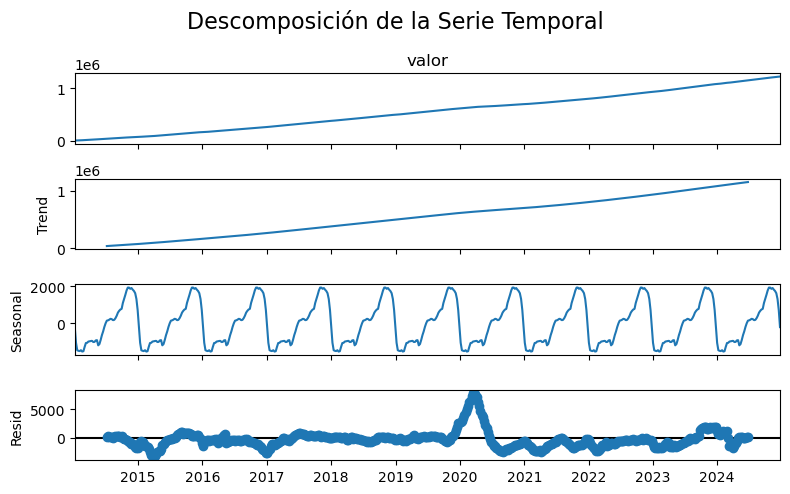

In [9]:
# Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido
decomposition = analyze_decomposition(ts_data, model='additive', figsize=(8, 5))

##### **Análisis de la Descomposición de la Serie**

**Tendencia (Trend):** Muestra un crecimiento lineal y casi perfecto a lo largo de toda la década (2014-2024). Al corregir los valores atípicos de la serie acumulada, se confirma que la fuerza dominante es una tendencia alcista ininterrumpida, indicando un aumento constante y predecible del número total de casos.

**Estacionalidad (Seasonal):** Revela un patrón anual, cíclico y muy bien definido, con un pico que se repite anualmente (sube y baja) pero que no tiene grandes variaciones en su amplitud. Este patrón confirma la influencia de los ciclos anuales (probablemente laborales o estacionales) en el reporte de casos.

**Residuos (Resid):** El ruido es ahora mucho más controlado y disperso alrededor de cero. El pico anómalo de 2020 (probablemente un efecto de la pandemia o un cambio en el reporte) que antes dominaba la gráfica ha sido tratado y disminuido, dejando un ruido residual manejable.

La serie de tiempo es **altamente predecible**. Está dominada por una **tendencia de crecimiento lineal** y una **estacionalidad anual clara**. Al corregir los valores atípicos, el modelo de descomposición es robusto y los componentes quedan bien separados.

#### Pruebas de estacionariedad

* Se aplican pruebas estadísticas para determinar si la serie es estacionaria, es decir, si sus propiedades estadísticas son constantes en el tiempo.

In [10]:
tester_ts_data = StationarityAnalyzer(ts_data)

tester_ts_data.run_test(test_type='ADF', show_report=True)
tester_ts_data.run_test(test_type='KPSS', show_report=True)


Resultados de la prueba ADF:
╒═════════════════╤════════════════╤════════════════════════╕
│ Métrica         │   Valor Prueba │   Valor Crítico (5.0%) │
╞═════════════════╪════════════════╪════════════════════════╡
│ Estadístico ADF │         3.3382 │                -2.8666 │
├─────────────────┼────────────────┼────────────────────────┤
│ p-value         │         1      │                 0.05   │
╘═════════════════╧════════════════╧════════════════════════╛

Resultados de la prueba KPSS:
╒══════════════════╤════════════════╤════════════════════════╕
│ Métrica          │   Valor Prueba │   Valor Crítico (5.0%) │
╞══════════════════╪════════════════╪════════════════════════╡
│ Estadístico KPSS │         3.4534 │                  0.463 │
├──────────────────┼────────────────┼────────────────────────┤
│ p-value          │         0.01   │                  0.05  │
╘══════════════════╧════════════════╧════════════════════════╛


c:\Users\steph\Documents\proyecto-integrador-mna\notebooks\modeling\../..\src\utils\ts_diagnostics.py:84: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.




##### Análisis de Resultados: Prueba ADF
Los resultados de la Prueba de Dickey-Fuller Aumentada (ADF) confirman que la serie de tiempo es claramente no estacionaria.

Dado que el Estadístico ADF (3.338) es mucho más grande (menos negativo) que el valor crítico al 5% (-2.866), y el Valor p es (mucho mayor que 0.05), no podemos rechazar la hipótesis nula. La serie de tiempo no es estacionaria y tiene una raíz unitaria. Esto es totalmente coherente con la fuerte tendencia de crecimiento que se observaron previamente.

##### Análisis de Resultados: Prueba KPSS
Los resultados de la Prueba de KPSS (Kwiatkowski-Phillips-Schmidt-Shin) complementan los hallazgos de la prueba ADF: la serie es no estacionaria.

En la prueba KPSS, la hipótesis nula es que la serie es estacionaria. Para rechazar esta hipótesis, el Estadístico debe ser mayor que el Valor Crítico, o el Valor p menor que 0.05. El Estadístico KPSS (3.453) es significativamente mayor que todos los valores críticos. 

Ambas pruebas (ADF y KPSS) concluyen que la serie de tiempo no es estacionaria. Esto se debe a la poderosa tendencia de crecimiento lineal que se han identificado en las gráficas de descomposición.

### Serie Original por Casos Semanales

* Se seleccionan las columnas relevantes y se grafica la serie temporal acumulada para observar su comportamiento general.

In [46]:
df_incremento = df_filtrado.copy()
df_incremento['valor'] = df_incremento['valor'].diff().fillna(0)
df_incremento.iloc[0, df_incremento.columns.get_loc('valor')] = 131

x= 'fecha'
y= 'valor'
title = 'Serie de tiempo General (Casos nuevos semanales)'
# Gráfica de línea con plotly / seaborn según selección del usuario
func.plot_timeseries(df_incremento, x=x, y=y, title=title, plotly_engine=USE_PLOTLY)

#### Descripción de gráfico
El nuevo gráfico de serie de tiempo con **Casos Nuevos Semanales** de depresión, revela una tendencia de **crecimiento sostenido** a largo plazo, a pesar de las fluctuaciones. Se observa una estacionalidad con caídas recurrentes (valles) al final de cada año. El período **2020-2021** muestra una interrupción y posterior recuperación en el ritmo de reporte, y los años recientes (2023-2024) exhiben **picos inusualmente altos** de casos nuevos, lo que sugiere un aumento en la detección o el reporte, aunque con una alta variabilidad.

#### Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido

* Se descompone la serie en sus componentes de tendencia, estacionalidad y ruido para identificar patrones subyacentes.

In [12]:
ts_data_incremento = df_incremento.set_index('fecha')['valor']

# Mostrar las primeras filas de la serie temporal preparada
print("Serie temporal preparada para descomposición:")
display(ts_data_incremento.head())

Serie temporal preparada para descomposición:


fecha
2014-01-06     131.0
2014-01-13     658.0
2014-01-20     933.0
2014-01-27    1023.0
2014-02-03    1151.0
Name: valor, dtype: float64

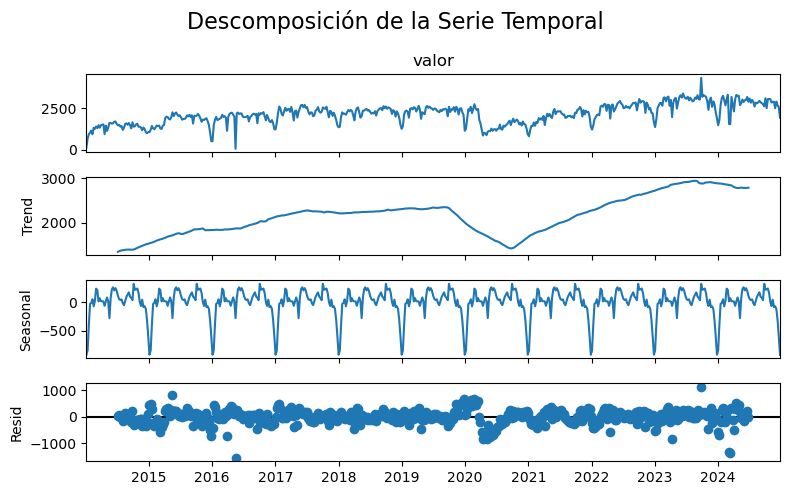

In [13]:
# Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido
decomposition = analyze_decomposition(ts_data_incremento, model='additive', figsize=(8, 5))

##### **Análisis de la Descomposición de la Serie**

**Tendencia (Trend):** La tendencia exhibe un crecimiento sostenido y gradual desde 2014 hasta 2019. Luego, muestra una caída abrupta que coincide con el inicio de 2020, seguida de una fuerte recuperación y un crecimiento continuo que alcanza su punto máximo a finales de 2023. Esta interrupción y posterior aceleración sugiere un impacto significativo del COVID-19 en el reporte de nuevos casos, seguido de una normalización y aumento en la detección.

**Estacionalidad (Seasonal):** Se revela un patrón cíclico anual extremadamente fuerte y bien definido. La estacionalidad es multiplicativa o aditiva con alta amplitud, caracterizada por caídas profundas y recurrentes (valles) al final de cada ciclo anual. Esto indica que el reporte de nuevos casos tiene un componente predecible que se ve afectado por factores estacionales o calendarios (como vacaciones de fin de año).

**Residuos (Resid):** Los residuos se dispersan de manera aleatoria alrededor de la línea cero, pero con la presencia de valores atípicos significativos. Se observan puntos extremos (tanto positivos como negativos) especialmente en el período 2020-2021, lo que sugiere que las semanas individuales de la pandemia tuvieron un ruido o anomalías que no son explicadas por la tendencia o el patrón estacional.

La serie de tiempo de casos nuevos semanales es no estacionaria debido a una fuerte tendencia de crecimiento a largo plazo (interrumpida en 2020) y una estacionalidad anual profunda y persistente. La presencia de un alto ruido en los residuos, especialmente alrededor de la pandemia, indica que esta serie requerirá diferenciación para eliminar la tendencia y potencialmente un tratamiento de valores atípicos antes de cualquier modelado predictivo robusto.

#### Pruebas de estacionariedad

* Se aplican pruebas estadísticas para determinar si la serie es estacionaria, es decir, si sus propiedades estadísticas son constantes en el tiempo.

In [14]:
tester_ts_data_incremento = StationarityAnalyzer(ts_data_incremento)

tester_ts_data_incremento.run_test(test_type='ADF', show_report=True)
tester_ts_data_incremento.run_test(test_type='KPSS', show_report=True)


Resultados de la prueba ADF:
╒═════════════════╤════════════════╤════════════════════════╕
│ Métrica         │   Valor Prueba │   Valor Crítico (5.0%) │
╞═════════════════╪════════════════╪════════════════════════╡
│ Estadístico ADF │        -2.577  │                -2.8667 │
├─────────────────┼────────────────┼────────────────────────┤
│ p-value         │         0.0978 │                 0.05   │
╘═════════════════╧════════════════╧════════════════════════╛

Resultados de la prueba KPSS:
╒══════════════════╤════════════════╤════════════════════════╕
│ Métrica          │   Valor Prueba │   Valor Crítico (5.0%) │
╞══════════════════╪════════════════╪════════════════════════╡
│ Estadístico KPSS │         1.8196 │                  0.463 │
├──────────────────┼────────────────┼────────────────────────┤
│ p-value          │         0.01   │                  0.05  │
╘══════════════════╧════════════════╧════════════════════════╛


c:\Users\steph\Documents\proyecto-integrador-mna\notebooks\modeling\../..\src\utils\ts_diagnostics.py:84: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.




##### Análisis de Resultados: Prueba ADF

El Estadístico ADF ($-2.577$) es mayor (menos negativo) que el valor crítico al $5\%$ ($-2.8667$), y el valor p ($0.0978$) es mayor que $0.05$. Por lo tanto, no se rechaza la hipótesis nula de no estacionariedad. La prueba ADF concluye que la serie de Casos Nuevos Semanales no es estacionaria.

##### Análisis de Resultados: Prueba KPSS

El Estadístico KPSS ($1.8196$) es significativamente mayor que el valor crítico al $5\%$ ($0.463$), y el valor p ($0.01$) es menor que $0.05$. Dado que la es de estacionariedad, esta hipótesis es rechazada. La prueba KPSS también concluye que la serie no es estacionaria.

### Serie Original por Casos Semanales (log)

* Se aplican transformaciones de logaritmo para estabilizar la varianza y facilitar la modelación.

In [15]:
df_log = df_incremento.copy()
df_log['valor'] = np.log1p(df_log['valor'])
x= 'fecha'
y= 'valor'
title = 'Serie de tiempo General (Casos nuevos semanales)'
# Gráfica de línea con plotly / seaborn según selección del usuario
func.plot_timeseries(df_log, x=x, y=y, title=title, plotly_engine=USE_PLOTLY)

#### Descripción de gráfico
El gráfico muestra la serie de tiempo de **Casos Nuevos Semanales después de aplicar la transformación logarítmica**. La transformación ha sido exitosa en **estabilizar la varianza**, haciendo que la amplitud de las fluctuaciones a lo largo del tiempo sea más uniforme, lo que es un pre-requisito esencial para el modelado. No obstante, la serie **aún exhibe claramente la tendencia de crecimiento** a largo plazo (la media sigue subiendo) y mantiene las caídas estacionales periódicas (valles) al final de cada año. La presencia de la tendencia y de la estacionalidad implica que la serie **todavía no es estacionaria**.

#### Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido

* Se descompone la serie en sus componentes de tendencia, estacionalidad y ruido para identificar patrones subyacentes.

In [16]:
ts_data_log = df_log.set_index('fecha')['valor']

# Mostrar las primeras filas de la serie temporal preparada
print("Serie temporal preparada para descomposición:")
display(ts_data_log.head())

Serie temporal preparada para descomposición:


fecha
2014-01-06    4.882802
2014-01-13    6.490724
2014-01-20    6.839476
2014-01-27    6.931472
2014-02-03    7.049255
Name: valor, dtype: float64

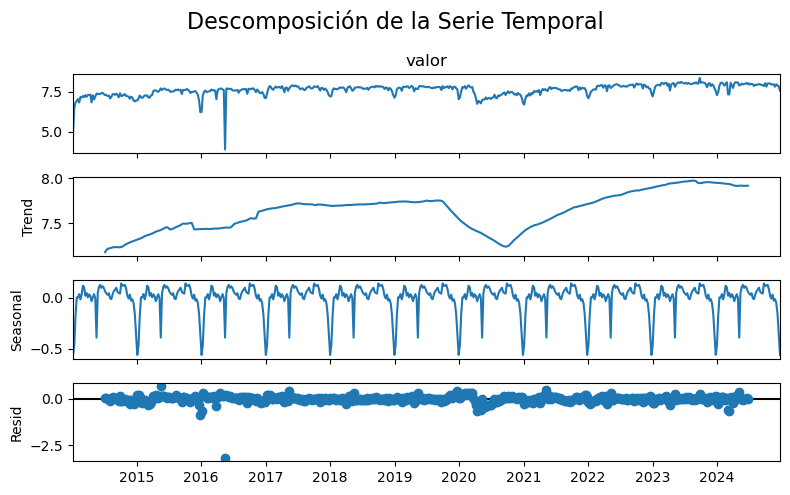

In [17]:
# Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido
decomposition = analyze_decomposition(ts_data_log, model='additive', figsize=(8, 5))

##### **Análisis de la Descomposición de la Serie**

**Tendencia (Trend):** La tendencia revela un crecimiento ascendente hasta finales de 2019, seguido de una caída abrupta durante 2020 y una fuerte recuperación y crecimiento continuo hasta 2023. La transformación logarítmica ha hecho que la pendiente de la tendencia sea más uniforme antes de la interrupción de 2020. A pesar de la transformación, la tendencia de crecimiento persiste, lo que confirma que la serie no es estacionaria en media.

**Estacionalidad (Seasonal):** Se mantiene un patrón cíclico anual muy fuerte y claro, caracterizado por valles recurrentes al final de cada ciclo anual. La transformación logarítmica fue efectiva en estabilizar la amplitud de estas caídas, haciendo que la estacionalidad sea aditiva, lo cual facilita la modelación.

**Residuos (Resid):** Muestran una varianza estable (la dispersión es uniforme) alrededor de la línea cero, lo cual es el efecto deseado de la transformación logarítmica. Sin embargo, persisten anomalías discretas (picos y valles), particularmente la perturbación vista en 2020-2021, que no es explicada por la tendencia o la estacionalidad.

La serie de tiempo logarítmica no es estacionaria debido a la persistencia de la tendencia y de una fuerte estacionalidad. La transformación logró estabilizar la varianza, pero la serie aún requiere un paso de diferenciación para eliminar la tendencia restante y cumplir con los requisitos de estacionariedad para modelos de pronóstico como SARIMA.

#### Pruebas de estacionariedad

* Se aplican pruebas estadísticas para determinar si la serie es estacionaria, es decir, si sus propiedades estadísticas son constantes en el tiempo.

In [18]:
tester_ts_data_log = StationarityAnalyzer(ts_data_log)

tester_ts_data_log.run_test(test_type='ADF', show_report=True)
tester_ts_data_log.run_test(test_type='KPSS', show_report=True)


Resultados de la prueba ADF:
╒═════════════════╤════════════════╤════════════════════════╕
│ Métrica         │   Valor Prueba │   Valor Crítico (5.0%) │
╞═════════════════╪════════════════╪════════════════════════╡
│ Estadístico ADF │        -4.223  │                -2.8667 │
├─────────────────┼────────────────┼────────────────────────┤
│ p-value         │         0.0006 │                 0.05   │
╘═════════════════╧════════════════╧════════════════════════╛

Resultados de la prueba KPSS:
╒══════════════════╤════════════════╤════════════════════════╕
│ Métrica          │   Valor Prueba │   Valor Crítico (5.0%) │
╞══════════════════╪════════════════╪════════════════════════╡
│ Estadístico KPSS │         1.7704 │                  0.463 │
├──────────────────┼────────────────┼────────────────────────┤
│ p-value          │         0.01   │                  0.05  │
╘══════════════════╧════════════════╧════════════════════════╛


c:\Users\steph\Documents\proyecto-integrador-mna\notebooks\modeling\../..\src\utils\ts_diagnostics.py:84: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.




##### Análisis de Resultados: Prueba ADF

El Estadístico ADF ($-4.223$) es significativamente menor (más negativo) que el valor crítico al $5\%$ ($-2.8667$). Además, el valor p ($0.0006$) es mucho menor que $0.05$. Por lo tanto, se rechaza la hipótesis nula de no estacionariedad. La prueba concluye que la serie logarítmica es estacionaria en media y varianza.


##### Análisis de Resultados: Prueba KPSS

Interpretación KPSS:
El Estadístico KPSS ($1.7704$) es sustancialmente mayor que el valor crítico al $5\%$ ($0.463$), y el valor p ($0.01$) es menor que $0.05$. Por lo tanto, la hipótesis nula de estacionariedad es rechazada. La prueba KPSS concluye que la serie logarítmica no es estacionaria.

### Serie Original por Casos Semanales (Box-Cox)

* Se aplican transformaciones de Box-Cox para estabilizar la varianza y facilitar la modelación.

In [19]:
from scipy import stats
df_boxcox = df_incremento.copy()
serie_transformada, lambda_optimo = stats.boxcox(df_boxcox['valor'])
df_boxcox['valor'] = serie_transformada

x= 'fecha'
y= 'valor'
title = 'Serie de tiempo General (Casos nuevos semanales)'
# Gráfica de línea con plotly / seaborn según selección del usuario
func.plot_timeseries(df_boxcox, x=x, y=y, title=title, plotly_engine=USE_PLOTLY)

#### Descripción de gráfico
El gráfico muestra la serie de tiempo de **Casos Nuevos Semanales después de aplicar la transformación Box-Cox**. Esta transformación ha logrado su objetivo de **estabilizar la varianza**, haciendo que las fluctuaciones a lo largo del tiempo sean de amplitud más uniforme. Sin embargo, la serie **aún conserva la tendencia de crecimiento** a largo plazo (la media sigue subiendo) y mantiene el **patrón estacional** de caídas recurrentes al final de cada ciclo anual. La persistencia de la tendencia y la estacionalidad implica que la serie **todavía no es estacionaria** y el siguiente paso obligatorio para el modelado es la diferenciación.

#### Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido

* Se descompone la serie en sus componentes de tendencia, estacionalidad y ruido para identificar patrones subyacentes.

In [20]:
ts_data_boxcox = df_boxcox.set_index('fecha')['valor']

# Mostrar las primeras filas de la serie temporal preparada
print("Serie temporal preparada para descomposición:")
display(ts_data_boxcox.head())

Serie temporal preparada para descomposición:


fecha
2014-01-06     265.810944
2014-01-13    1789.200275
2014-01-20    2701.687877
2014-01-27    3011.824805
2014-02-03    3461.348526
Name: valor, dtype: float64

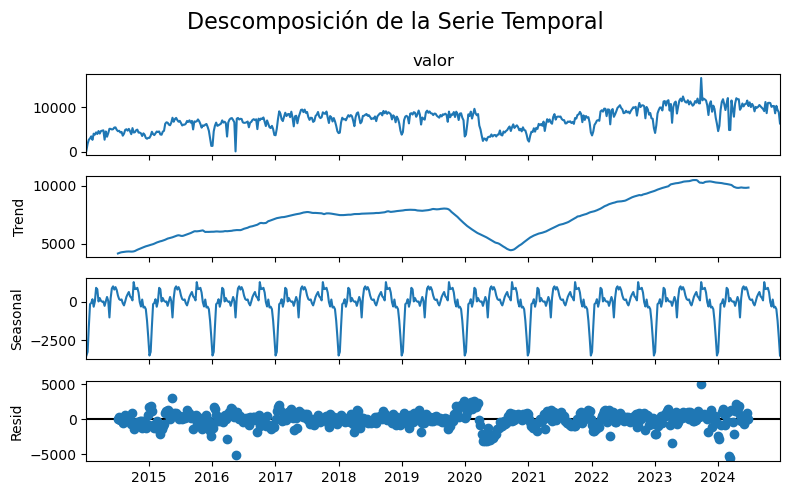

In [21]:
# Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido
decomposition = analyze_decomposition(ts_data_boxcox, model='additive', figsize=(8, 5))

##### **Análisis de la Descomposición de la Serie**

**Tendencia (Trend):** La tendencia es la componente dominante y exhibe un crecimiento ascendente hasta finales de 2019, seguido de una caída visible en 2020 y una fuerte recuperación y crecimiento continuo hasta un pico en 2023. Esto confirma que la media de la serie cambia con el tiempo y que la transformación Box-Cox, por sí sola, no ha logrado eliminar la tendencia.

**Estacionalidad (Seasonal):** Se revela un patrón cíclico anual muy fuerte y claro con caídas recurrentes (valles) al final de cada ciclo anual. La transformación Box-Cox ha sido efectiva en estabilizar la amplitud de estas fluctuaciones, haciendo que el componente estacional sea más uniforme a lo largo de los años, lo cual es favorable para el modelado.

**Residuos (Resid):** El componente residual muestra una varianza estable alrededor de cero, demostrando el éxito de Box-Cox en el tratamiento de la varianza. Sin embargo, persisten anomalías discretas (puntos aislados) en la serie, lo cual es ruido no explicado por la tendencia o la estacionalidad, destacando el impacto de eventos atípicos (como el periodo de la pandemia).

La serie de tiempo post-Box-Cox no es estacionaria debido a la persistencia de la tendencia y de una fuerte estacionalidad. La transformación logró estabilizar la varianza, pero la serie aún requiere un paso de diferenciación para eliminar la tendencia restante y cumplir con los requisitos de estacionariedad para modelos de pronóstico.

#### Pruebas de estacionariedad

* Se aplican pruebas estadísticas para determinar si la serie es estacionaria, es decir, si sus propiedades estadísticas son constantes en el tiempo.

In [22]:
tester_ts_data_boxcox = StationarityAnalyzer(ts_data_boxcox)

tester_ts_data_boxcox.run_test(test_type='ADF', show_report=True)
tester_ts_data_boxcox.run_test(test_type='KPSS', show_report=True)


Resultados de la prueba ADF:
╒═════════════════╤════════════════╤════════════════════════╕
│ Métrica         │   Valor Prueba │   Valor Crítico (5.0%) │
╞═════════════════╪════════════════╪════════════════════════╡
│ Estadístico ADF │        -2.215  │                -2.8668 │
├─────────────────┼────────────────┼────────────────────────┤
│ p-value         │         0.2008 │                 0.05   │
╘═════════════════╧════════════════╧════════════════════════╛

Resultados de la prueba KPSS:
╒══════════════════╤════════════════╤════════════════════════╕
│ Métrica          │   Valor Prueba │   Valor Crítico (5.0%) │
╞══════════════════╪════════════════╪════════════════════════╡
│ Estadístico KPSS │         1.8468 │                  0.463 │
├──────────────────┼────────────────┼────────────────────────┤
│ p-value          │         0.01   │                  0.05  │
╘══════════════════╧════════════════╧════════════════════════╛


c:\Users\steph\Documents\proyecto-integrador-mna\notebooks\modeling\../..\src\utils\ts_diagnostics.py:84: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.




##### Análisis de Resultados: Prueba ADF

El Estadístico ADF ($-2.215$) es mayor (menos negativo) que el valor crítico al $5\%$ ($-2.8668$). De manera contundente, el valor p ($0.2008$) es significativamente mayor que el nivel de significancia de $0.05$. Por lo tanto, no se rechaza la hipótesis nula de no estacionariedad. La prueba confirma que la serie Box-Cox no es estacionaria.


##### Análisis de Resultados: Prueba KPSS

El Estadístico KPSS ($1.8468$) es sustancialmente mayor que el valor crítico al $5\%$ ($0.463$). El valor p ($0.01$) es menor que $0.05$. La hipótesis nula de estacionariedad es rechazada. La prueba KPSS también confirma que la serie no es estacionaria.

### Serie Original por Casos Semanales (log + Diff)

* Se seleccionan las columnas relevantes y se grafica la serie temporal acumulada para observar su comportamiento general.

In [23]:
df_log_diff = df_log.copy()
df_diff1 = df_log_diff.set_index('fecha').diff().dropna().reset_index()

x= 'fecha'
y= 'valor'
title = 'Serie de tiempo General (Casos nuevos semanales)'
# Gráfica de línea con plotly / seaborn según selección del usuario
func.plot_timeseries(df_diff1, x=x, y=y, title=title, plotly_engine=USE_PLOTLY)

#### Descripción de gráfico
El gráfico muestra la serie de tiempo de **Casos Nuevos Semanales después de aplicar una diferenciación a la serie transformada logarítmicamente (Log-Diff)**. La diferenciación ha sido **completamente exitosa en eliminar la tendencia** y estabilizar la media de la serie, la cual ahora oscila de manera estable alrededor de cero, cumpliendo con el requisito fundamental de **estacionariedad**. La varianza también es constante, con la mayor parte del ruido concentrada cerca de la línea de base, a excepción de un **valor atípico extremo** alrededor de 2016 y otro al inicio de 2014, lo que sugiere anomalías en el registro de la tasa de crecimiento durante esas semanas.

#### Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido

* Se descompone la serie en sus componentes de tendencia, estacionalidad y ruido para identificar patrones subyacentes.

In [24]:
ts_data_diff1 = df_diff1.set_index('fecha')['valor']

# Mostrar las primeras filas de la serie temporal preparada
print("Serie temporal preparada para descomposición:")
display(ts_data_diff1.head())

Serie temporal preparada para descomposición:


fecha
2014-01-13    1.607922
2014-01-20    0.348753
2014-01-27    0.091995
2014-02-03    0.117783
2014-02-10   -0.216223
Name: valor, dtype: float64

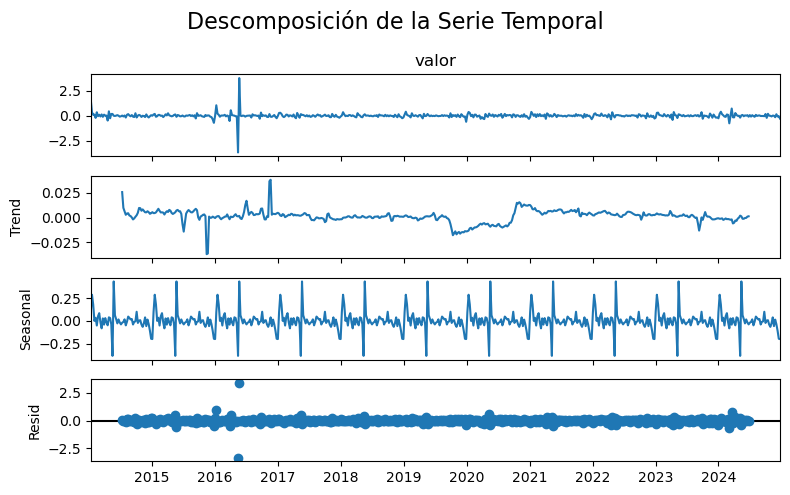

In [25]:
# Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido
decomposition = analyze_decomposition(ts_data_diff1, model='additive', figsize=(8, 5))

##### **Análisis de la Descomposición de la Serie**

**Tendencia (Trend):** La tendencia se ha eliminado por completo, mostrando ahora una línea plana y estable alrededor de cero. Esto confirma que la diferenciación fue exitosa en inducir la estacionariedad en la media, eliminando el crecimiento a largo plazo.

**Estacionalidad (Seasonal):** El patrón cíclico anual persiste, con picos y valles recurrentes, aunque su amplitud se mantiene cerca de cero. Esta estacionalidad no fue eliminada por la diferenciación simple, lo cual es esperado. Este componente estacional deberá ser capturado por la parte estacional ($D=0$) de un modelo SARIMA o con una diferenciación estacional adicional.

**Residuos (Resid):** Muestran una varianza estable con los puntos dispersándose de manera uniforme alrededor de la línea cero. La mayoría de los valores atípicos previos se han mitigado o normalizado, dejando una serie con un ruido más aleatorio y una varianza constante.

La serie de tiempo es estacionaria en media y varianza, gracias a la transformación logarítmica y la diferenciación. El éxito en la eliminación de la tendencia y la preservación de la estacionalidad restante hacen que esta serie esté lista para la aplicación de un modelo SARIMA para el pronóstico.

#### Pruebas de estacionariedad

* Se aplican pruebas estadísticas para determinar si la serie es estacionaria, es decir, si sus propiedades estadísticas son constantes en el tiempo.

In [26]:
tester_ts_data_diff1 = StationarityAnalyzer(ts_data_diff1)

tester_ts_data_diff1.run_test(test_type='ADF', show_report=True)
tester_ts_data_diff1.run_test(test_type='KPSS', show_report=True)


Resultados de la prueba ADF:
╒═════════════════╤════════════════╤════════════════════════╕
│ Métrica         │   Valor Prueba │   Valor Crítico (5.0%) │
╞═════════════════╪════════════════╪════════════════════════╡
│ Estadístico ADF │        -7.9522 │                -2.8668 │
├─────────────────┼────────────────┼────────────────────────┤
│ p-value         │         0      │                 0.05   │
╘═════════════════╧════════════════╧════════════════════════╛

Resultados de la prueba KPSS:
╒══════════════════╤════════════════╤════════════════════════╕
│ Métrica          │   Valor Prueba │   Valor Crítico (5.0%) │
╞══════════════════╪════════════════╪════════════════════════╡
│ Estadístico KPSS │         0.3101 │                  0.463 │
├──────────────────┼────────────────┼────────────────────────┤
│ p-value          │         0.1    │                  0.05  │
╘══════════════════╧════════════════╧════════════════════════╛


c:\Users\steph\Documents\proyecto-integrador-mna\notebooks\modeling\../..\src\utils\ts_diagnostics.py:84: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




##### Análisis de Resultados: Prueba ADF

Estadístico ADF ($-7.9522$) es mucho más negativo que el valor crítico al $5\%$ ($-2.8668$), y el valor p es $0$ (menor que $0.05$). Por lo tanto, se rechaza contundentemente la hipótesis nula de no estacionariedad. La prueba confirma que la serie es estacionaria en media.


##### Análisis de Resultados: Prueba KPSS

El Estadístico KPSS ($0.3101$) es menor que el valor crítico al $5\%$ ($0.463$). El valor p ($0.1$) es mayor que $0.05$. Por lo tanto, no se rechaza la hipótesis nula de estacionariedad. La prueba confirma que la serie es estacionaria.


Ambas pruebas coinciden plenamente en que la serie de tiempo Log-Diff es estacionaria. La diferenciación fue exitosa en eliminar la tendencia y cualquier raíz unitaria, cumpliendo de forma robusta con el requisito fundamental para el ajuste de modelos de pronóstico paramétricos como SARIMA.

## Exponential Smoothing

In [27]:
# Se importa el modelo Holt de la librería statsmodels para aplicar suavizamiento exponencial doble.
from statsmodels.tsa.holtwinters import Holt

### Modelo Holt (df_log)

* Se ordena el DataFrame por fecha, se establece el índice temporal y se divide el conjunto de datos en entrenamiento (80%) y prueba (20%) para validar el modelo.

In [28]:
# índice temporal
df = df_log.copy()
data = df.sort_values('fecha').set_index('fecha').asfreq('W-MON')
# data = data.set_index('fecha').asfreq('W-MON')
train, test = func.split_series(data, train_size=0.8)

Total de datos: 573
Tamaño del conjunto de entrenamiento: 458
Tamaño del conjunto de prueba: 115


* Se ajusta el modelo de suavizamiento exponencial doble utilizando únicamente el conjunto de entrenamiento.

In [29]:
# model_double = Holt(data)
model_double = Holt(train)
model_double_fit = model_double.fit()

* Se realiza el pronóstico para el periodo de prueba utilizando el modelo ajustado.

In [30]:
forecast_double = model_double_fit.forecast(115)
# print(forecast_double)

* Se transforman los valores ajustados y pronosticados de la escala logarítmica a la escala original para facilitar la interpretación

In [31]:
scaled_method = 'log'
df_original = func.get_original_scale_dataframe(data, method=scaled_method)
df_ajustado = func.get_original_scale_dataframe(model_double_fit.fittedvalues, method=scaled_method)
df_pronostico = func.get_original_scale_dataframe(forecast_double, method=scaled_method)

#### Visualización de resultados
* Se grafican los datos originales, los valores ajustados y el pronóstico para comparar el desempeño del modelo.

In [32]:
# --- 1. Define los argumentos que NUNCA cambian ---
# Los datos a graficar
model_name = 'Modelo Holt / Double Exponential Smoothing'
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
)

# Los parámetros comunes del gráfico
common_plot_args = {
    'plotly_engine': USE_PLOTLY,
    'hover_mode': 'x unified',
}

# --- 2. Crea la lista de gráficos a generar ---
# El gráfico base que siempre se muestra
plot_configs = [
    ('valor', 'valor_log')
]

# El gráfico condicional
if 'valor_original' in df_original.columns:
    plot_configs.append(('valor_original', 'valor_original'))


# --- 3. Itera y llama a la función UNA SOLA VEZ dentro del bucle ---
for y_col, title_suffix in plot_configs:
    func.plot_forecast(
        *data_tuples,  # Desempaqueta los datos
        y=y_col,
        title=f'Comparación de Series {model_name} ({title_suffix})',
        **common_plot_args  # Desempaqueta los argumentos comunes
    )

#### Evaluación del modelo

Se calculan las métricas de error (MAE y RMSE) tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

In [33]:
func.evaluate_model_performance(train,test,df_ajustado,df_pronostico, label= 'valor')

Evaluating model performance...
Evaluación del modelo en el conjunto de Entrenamiento:
╒═══════════╤══════════╕
│ Métrica   │    Valor │
╞═══════════╪══════════╡
│ MAE       │ 0.142898 │
├───────────┼──────────┤
│ RMSE      │ 0.319797 │
╘═══════════╧══════════╛
Evaluación del modelo en el conjunto de Entrenamiento:
╒═══════════╤══════════╕
│ Métrica   │    Valor │
╞═══════════╪══════════╡
│ MAE       │ 0.967485 │
├───────────┼──────────┤
│ RMSE      │ 1.11136  │
╘═══════════╧══════════╛


In [34]:
func.plot_residuals_over_time(train,df_ajustado, plotly_engine = USE_PLOTLY, title = 'Análisis de Errores - Conjunto de Entrenamiento')
func.plot_residuals_over_time(test, df_pronostico, plotly_engine = USE_PLOTLY, title = 'Análisis de Errores - Conjunto de Prueba')

La evaluación del modelo muestra un bajo error absoluto medio (MAE) y raíz del error cuadrático medio (RMSE) tanto en el conjunto de entrenamiento como en el de prueba. Esto indica que el modelo de suavizamiento exponencial doble logra un ajuste preciso y generaliza adecuadamente a datos no vistos.

* Se genera un pronóstico adicional para un periodo más largo y se visualiza junto con los datos originales y ajustados.

In [35]:
forecast_double2 = model_double_fit.forecast(200)
df_pronostico2 = func.get_original_scale_dataframe(forecast_double2, method='log')

In [36]:
# --- 1. Define los argumentos que NUNCA cambian ---
# Los datos a graficar
model_name = 'Modelo Holt / Double Exponential Smoothing'
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico2, 'Pronosticada'),
)

# Los parámetros comunes del gráfico
common_plot_args = {
    'plotly_engine': USE_PLOTLY,
    'hover_mode': 'x unified',
}

# --- 2. Crea la lista de gráficos a generar ---
# El gráfico base que siempre se muestra
plot_configs = [
    ('valor', 'valor_log')
]

# El gráfico condicional
if 'valor_original' in df_original.columns:
    plot_configs.append(('valor_original', 'valor_original'))


# --- 3. Itera y llama a la función UNA SOLA VEZ dentro del bucle ---
for y_col, title_suffix in plot_configs:
    func.plot_forecast(
        *data_tuples,  # Desempaqueta los datos
        y=y_col,
        title=f'Comparación de Series {model_name} ({title_suffix})',
        **common_plot_args  # Desempaqueta los argumentos comunes
    )

## x

In [37]:
from statsmodels.tsa.api import ExponentialSmoothing

# índice temporal
# data = df_log.sort_values('fecha')
# data = df_filtrado.copy().sort_values('fecha')
data = df_log.copy().sort_values('fecha')
data = data.set_index('fecha').asfreq('W-MON')
train, test = func.split_series(data, train_size=0.8)


Total de datos: 573
Tamaño del conjunto de entrenamiento: 458
Tamaño del conjunto de prueba: 115


In [38]:
model_triple = ExponentialSmoothing(
    train, 
    seasonal_periods=52, 
    trend='mul', 
    seasonal='add')

model_triple_fit = model_triple.fit()

In [39]:
# forecast_triple = model_triple_fit.forecast(115)
forecast_triple = model_triple_fit.forecast(115)


In [40]:
method = 'log'
df_original = func.get_original_scale_dataframe(data, method=method)

df_ajustado = func.get_original_scale_dataframe(model_triple_fit.fittedvalues, method=method)

df_pronostico = func.get_original_scale_dataframe(forecast_triple, method=method)

In [41]:
func.evaluate_model_performance(train,test,df_ajustado,df_pronostico, label= 'valor')

Evaluating model performance...
Evaluación del modelo en el conjunto de Entrenamiento:
╒═══════════╤══════════╕
│ Métrica   │    Valor │
╞═══════════╪══════════╡
│ MAE       │ 0.111691 │
├───────────┼──────────┤
│ RMSE      │ 0.225802 │
╘═══════════╧══════════╛
Evaluación del modelo en el conjunto de Entrenamiento:
╒═══════════╤══════════╕
│ Métrica   │    Valor │
╞═══════════╪══════════╡
│ MAE       │ 0.132018 │
├───────────┼──────────┤
│ RMSE      │ 0.188526 │
╘═══════════╧══════════╛


In [42]:
# --- 1. Define los argumentos que NUNCA cambian ---
# Los datos a graficar
model_name = 'Holt-Winters / Triple Exponential Smoothing'
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'),
)

# Los parámetros comunes del gráfico
common_plot_args = {
    'plotly_engine': USE_PLOTLY,
    # 'hover_mode': 'x unified',
}

# --- 2. Crea la lista de gráficos a generar ---
# El gráfico base que siempre se muestra
plot_configs = [
    ('valor', 'Valor Semanal')
]

# El gráfico condicional
if 'valor_original' in df_original.columns:
    plot_configs.append(('valor_original', 'valor_original'))


# --- 3. Itera y llama a la función UNA SOLA VEZ dentro del bucle ---
for y_col, title_suffix in plot_configs:
    func.plot_forecast(
        *data_tuples,  # Desempaqueta los datos
        y=y_col,
        title=f'Comparación de Series {model_name} ({title_suffix})',
        **common_plot_args  # Desempaqueta los argumentos comunes
    )

In [43]:
forecast_triple = model_triple_fit.forecast(200)
df_pronostico2 = func.get_original_scale_dataframe(forecast_triple, method=method)

In [44]:
# --- 1. Define los argumentos que NUNCA cambian ---
# Los datos a graficar
model_name = 'Modelo Holt / Double Exponential Smoothing'
data_tuples = (
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico2, 'Pronosticada'),
)

# Los parámetros comunes del gráfico
common_plot_args = {
    'plotly_engine': USE_PLOTLY,
    # 'hover_mode': 'x unified',
}

# --- 2. Crea la lista de gráficos a generar ---
# El gráfico base que siempre se muestra
plot_configs = [
    ('valor', 'Valor Semanal')
]

# El gráfico condicional
if 'valor_original' in df_original.columns:
    plot_configs.append(('valor_original', 'valor_original'))


# --- 3. Itera y llama a la función UNA SOLA VEZ dentro del bucle ---
for y_col, title_suffix in plot_configs:
    func.plot_forecast(
        *data_tuples,  # Desempaqueta los datos
        y=y_col,
        title=f'Comparación de Series {model_name} ({title_suffix})',
        **common_plot_args  # Desempaqueta los argumentos comunes
    )

In [45]:
func.plot_residuals_over_time(train,df_ajustado, plotly_engine = USE_PLOTLY, title = 'Análisis de Errores - Conjunto de Entrenamiento')
func.plot_residuals_over_time(test, df_pronostico, plotly_engine = USE_PLOTLY, title = 'Análisis de Errores - Conjunto de Prueba')